In [ ]:
#read dataset structure - columns available and needed columns analysis (feature selection)

In [ ]:
import pandas as pd
df=pd.read_csv('/content/accepted_2007_to_2018Q4.csv',nrows=1000)
print(df.head())
print(df.columns)

         id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0  68407277        NaN     3600.0       3600.0           3600.0   36 months   
1  68355089        NaN    24700.0      24700.0          24700.0   36 months   
2  68341763        NaN    20000.0      20000.0          20000.0   60 months   
3  66310712        NaN    35000.0      35000.0          35000.0   60 months   
4  68476807        NaN    10400.0      10400.0          10400.0   60 months   

   int_rate  installment grade sub_grade  ... hardship_payoff_balance_amount  \
0     13.99       123.03     C        C4  ...                            NaN   
1     11.99       820.28     C        C1  ...                            NaN   
2     10.78       432.66     B        B4  ...                            NaN   
3     14.85       829.90     C        C5  ...                            NaN   
4     22.45       289.91     F        F1  ...                            NaN   

  hardship_last_payment_amount disbursement_

In [ ]:
pd.set_option('display.max_columns',None)
print(df.columns)
df.head().T

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlement_term'],
      dtype='object', length=151)


,0,1,2,3,4
id,68407277,68355089,68341763,66310712,68476807
member_id,NaN,NaN,NaN,NaN,NaN
loan_amnt,3600.0,24700.0,20000.0,35000.0,10400.0
funded_amnt,3600.0,24700.0,20000.0,35000.0,10400.0
funded_amnt_inv,3600.0,24700.0,20000.0,35000.0,10400.0
...,...,...,...,...,...
settlement_status,NaN,NaN,NaN,NaN,NaN
settlement_date,NaN,NaN,NaN,NaN,NaN
settlement_amount,NaN,NaN,NaN,NaN,NaN
settlement_percentage,NaN,NaN,NaN,NaN,NaN


In [ ]:
selected_features = [
    'loan_amnt', # requested loan
    'term', # loan duration
    'int_rate',# interest %
    'installment',# monthly payment
    'grade',# credit grade (A–G)
    'emp_length',# years working
    'home_ownership',# rent/own
    'annual_inc',# income
    'verification_status',# income verified?
    'purpose',# purpose
    'dti',# debt/income ratio
    'delinq_2yrs',# past missed payments
    'inq_last_6mths',# credit checks
    'open_acc',# active accounts
    'pub_rec',# public records
    'revol_util',# usage %
    'earliest_cr_line',# credit start
    'total_acc',# total accounts
    'loan_status'   # target
]
new_df=df[selected_features].copy()
print(new_df.head())

   loan_amnt        term  int_rate  installment grade emp_length  \
0     3600.0   36 months     13.99       123.03     C  10+ years   
1    24700.0   36 months     11.99       820.28     C  10+ years   
2    20000.0   60 months     10.78       432.66     B  10+ years   
3    35000.0   60 months     14.85       829.90     C  10+ years   
4    10400.0   60 months     22.45       289.91     F    3 years   

  home_ownership  annual_inc verification_status             purpose    dti  \
0       MORTGAGE     55000.0        Not Verified  debt_consolidation   5.91   
1       MORTGAGE     65000.0        Not Verified      small_business  16.06   
2       MORTGAGE     63000.0        Not Verified    home_improvement  10.78   
3       MORTGAGE    110000.0     Source Verified  debt_consolidation  17.06   
4       MORTGAGE    104433.0     Source Verified      major_purchase  25.37   

   delinq_2yrs  inq_last_6mths  open_acc  pub_rec  revol_util  \
0          0.0             1.0       7.0      0.0  

In [ ]:
new_df=new_df[new_df['loan_status'].isin(['Fully Paid','Charged Off'])]
new_df['target']=new_df['loan_status'].map({
    'Fully Paid':0,
    'Charged Off':1
})
new_df.drop('loan_status',axis=1,inplace=True)
new_df.head()

#target extraction

,loan_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_util,earliest_cr_line,total_acc,target
0,3600.0,36 months,13.99,123.03,C,10+ years,MORTGAGE,55000.0,Not Verified,debt_consolidation,5.91,0.0,1.0,7.0,0.0,29.7,Aug-2003,13.0,0
1,24700.0,36 months,11.99,820.28,C,10+ years,MORTGAGE,65000.0,Not Verified,small_business,16.06,1.0,4.0,22.0,0.0,19.2,Dec-1999,38.0,0
2,20000.0,60 months,10.78,432.66,B,10+ years,MORTGAGE,63000.0,Not Verified,home_improvement,10.78,0.0,0.0,6.0,0.0,56.2,Aug-2000,18.0,0
4,10400.0,60 months,22.45,289.91,F,3 years,MORTGAGE,104433.0,Source Verified,major_purchase,25.37,1.0,3.0,12.0,0.0,64.5,Jun-1998,35.0,0
5,11950.0,36 months,13.44,405.18,C,4 years,RENT,34000.0,Source Verified,debt_consolidation,10.20,0.0,0.0,5.0,0.0,68.4,Oct-1987,6.0,0


In [ ]:
# converting term to number
#new_df['term']=new_df['term'].str.extract(r'(\d+)').astype(int)

# handling the experience of employee along with missing values
new_df['emp_length']=new_df['emp_length'].str.extract(r'(\d+)')
new_df['emp_length']=new_df['emp_length'].fillna(0).astype(int)

# to handle the early credit history to years of credit usage
new_df['earliest_cr_line']=pd.to_datetime(new_df['earliest_cr_line'])
import datetime
new_df['credit_card_usage_in_years']=datetime.datetime.now().year-new_df['earliest_cr_line'].dt.year
new_df.drop('earliest_cr_line',axis=1,inplace=True)


/tmp/ipykernel_3235/267800478.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  new_df['earliest_cr_line']=pd.to_datetime(new_df['earliest_cr_line'])


In [ ]:
new_df.head()
new_df.info()
new_df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 873 entries, 0 to 999
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   loan_amnt                   873 non-null    float64
 1   term                        873 non-null    object 
 2   int_rate                    873 non-null    float64
 3   installment                 873 non-null    float64
 4   grade                       873 non-null    object 
 5   emp_length                  873 non-null    int64  
 6   home_ownership              873 non-null    object 
 7   annual_inc                  873 non-null    float64
 8   verification_status         873 non-null    object 
 9   purpose                     873 non-null    object 
 10  dti                         873 non-null    float64
 11  delinq_2yrs                 873 non-null    float64
 12  inq_last_6mths              873 non-null    float64
 13  open_acc                    873 non-null

,loan_amnt,int_rate,installment,emp_length,annual_inc,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_util,total_acc,target,credit_card_usage_in_years
count,873.000000,873.000000,873.000000,873.000000,873.000000,873.000000,873.000000,873.000000,873.000000,873.000000,873.000000,873.000000,873.000000,873.000000
mean,14924.054983,11.792829,447.911707,5.674685,79421.277010,19.135647,0.333333,0.607102,12.450172,0.232532,49.243757,26.279496,0.166094,27.830470
std,8675.966610,4.410393,258.247786,3.774858,42055.600733,8.324922,0.933574,0.922599,5.557259,0.545831,23.136832,12.318397,0.372378,7.592466
min,1000.000000,5.320000,32.970000,0.000000,13000.000000,0.630000,0.000000,0.000000,2.000000,0.000000,0.000000,4.000000,0.000000,14.000000
25%,8000.000000,8.490000,256.050000,2.000000,50000.000000,13.270000,0.000000,0.000000,9.000000,0.000000,31.300000,18.000000,0.000000,23.000000
50%,14000.000000,11.480000,391.620000,5.000000,70000.000000,18.470000,0.000000,0.000000,12.000000,0.000000,47.800000,24.000000,0.000000,26.000000
75%,20000.000000,13.990000,612.890000,10.000000,100000.000000,24.830000,0.000000,1.000000,15.000000,0.000000,66.300000,33.000000,0.000000,32.000000
max,35000.000000,28.490000,1252.560000,10.000000,450000.000000,46.710000,15.000000,5.000000,46.000000,5.000000,102.000000,89.000000,1.000000,69.000000


In [ ]:
new_df.isnull().sum()
new_df.fillna(new_df.median(numeric_only=True),inplace=True)
new_df.fillna('unknown',inplace=True)
# convert categorical to numerical and drop the first one it will be automatically
#stimulated once remaining input is zero
new_df=pd.get_dummies(new_df,drop_first=True)

In [ ]:
new_df['target'].value_counts(normalize=True) * 100

,proportion
target,
0,83.390607
1,16.609393


In [ ]:
# baseline accuracy using logistic regression
x=new_df.drop('target',axis=1)
y=new_df['target']

from sklearn.model_selection import train_test_split

xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

# use of standardscalar model to make the standard distribution spread across to one and mean centered to the origin
#so as larger values does not dominate and ignore small values
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
xtrsc=scaler.fit_transform(xtrain)
xtesc=scaler.transform(xtest)

from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)
model.fit(xtrsc,ytrain)

ypred=model.predict(xtesc)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(ytest, ypred))
print("\nClassification Report:\n", classification_report(ytest, ypred))
print("\nConfusion Matrix:\n", confusion_matrix(ytest, ypred))

# class imbalance affects the accuracy of the model (high precision-nearly one and
# low recall- nearly zero )

# for good model recall > 0.7 good  0.5 to 0.7 acceptable  <0.4 bad <0.2 severe problem
# this model recall=0.15 ==0.1 very bad

#precision is high like 1.0.. very bad

#f1-score  >0.6 - decent <0.4 -weak (model is 0.27 -poor)

Accuracy: 0.8742857142857143

Classification Report:
               precision    recall  f1-score   support

           0       0.87      1.00      0.93       149
           1       1.00      0.15      0.27        26

    accuracy                           0.87       175
   macro avg       0.94      0.58      0.60       175
weighted avg       0.89      0.87      0.83       175


Confusion Matrix:
 [[149   0]
 [ 22   4]]


In [ ]:
x=new_df.drop('target',axis=1)
y=new_df['target']

from sklearn.model_selection import train_test_split

xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

# use of weighted scalar model so as to give same weight for each class so as to
# give equal importance and avoid class imbalance and model must predict the pattern
# instead of going to safety way
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
xtrsc=scaler.fit_transform(xtrain)
xtesc=scaler.transform(xtest)

from sklearn.linear_model import LogisticRegression
model=LogisticRegression(
    class_weight='balanced',
    max_iter=1000)
model.fit(xtrsc,ytrain)

ypred=model.predict(xtesc)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(ytest, ypred))
print("\nClassification Report:\n", classification_report(ytest, ypred))
print("\nConfusion Matrix:\n", confusion_matrix(ytest, ypred))

Accuracy: 0.6742857142857143

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.66      0.78       149
           1       0.28      0.73      0.40        26

    accuracy                           0.67       175
   macro avg       0.60      0.70      0.59       175
weighted avg       0.84      0.67      0.72       175


Confusion Matrix:
 [[99 50]
 [ 7 19]]



🔹 Threshold: 0.6
Confusion Matrix:
[[119  30]
 [ 10  16]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.80      0.86       149
           1       0.35      0.62      0.44        26

    accuracy                           0.77       175
   macro avg       0.64      0.71      0.65       175
weighted avg       0.84      0.77      0.79       175

   Threshold  Precision    Recall        F1
0        0.6   0.347826  0.615385  0.444444


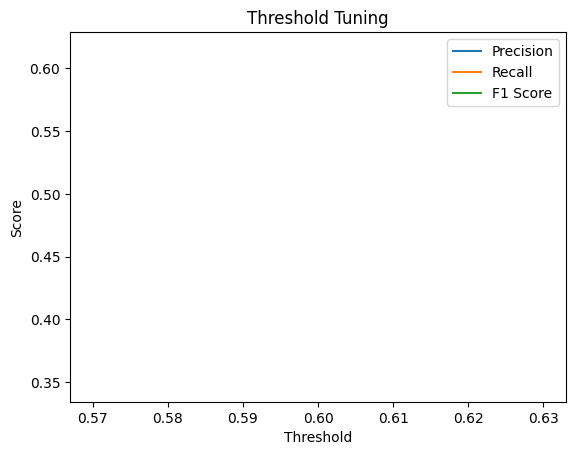

In [ ]:
x=new_df.drop('target',axis=1)
y=new_df['target']

from sklearn.model_selection import train_test_split

xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
xtrsc=scaler.fit_transform(xtrain)
xtesc=scaler.transform(xtest)

from sklearn.linear_model import LogisticRegression
model=LogisticRegression(
    class_weight='balanced',
    max_iter=1000)
model.fit(xtrsc,ytrain)
y_prob = model.predict_proba(xtesc)[:, 1]

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

results = []


print(f"\n🔹 Threshold: {0.6}")

y_pred_t = (y_prob > 0.6).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(ytest, y_pred_t))

print("\nClassification Report:")
print(classification_report(ytest, y_pred_t))

precision = precision_score(ytest, y_pred_t)
recall = recall_score(ytest, y_pred_t)
f1 = f1_score(ytest, y_pred_t)

results.append([0.6, precision, recall, f1])
results_df = pd.DataFrame(results, columns=['Threshold', 'Precision', 'Recall', 'F1'])
print(results_df)
import matplotlib.pyplot as plt

plt.plot(results_df['Threshold'], results_df['Precision'], label='Precision')
plt.plot(results_df['Threshold'], results_df['Recall'], label='Recall')
plt.plot(results_df['Threshold'], results_df['F1'], label='F1 Score')

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning")
plt.legend()
plt.show()

In [ ]:
'''Order of fixing

You said:

imbalance → weights → threshold

Correct flow is:

1. Train baseline
2. Check recall/precision
3. If minority recall low → try class_weight
4. Then tune threshold

When a model shows high precision but low recall for the minority class, it often indicates that the model is too conservative, which can be caused by class imbalance or an inappropriate decision threshold.

To address this, we first use techniques like class_weight to make the model pay more attention to the minority class, and then tune the decision threshold to balance precision and recall based on business requirements.

Additionally, scaling (like StandardScaler) is used to normalize feature ranges so that all features contribute equally to models like logistic regression.

Now: Scaling (Your Statement)

You said:

“Scaling means making each feature in same level”

That’s correct—but let’s refine it.

What scaling REALLY means

Making all features comparable in magnitude

Imagine you are a security guard at a mall

Your job: catch thieves

Case 1: High Recall, Low Precision

You stop almost everyone suspicious

You catch all thieves
But also stop many innocent people
What this means
Recall = HIGH → you didn’t miss thieves
Precision = LOW → many wrong accusations
Model behavior

Model is aggressive

“Better to suspect more than miss a thief”

Case 2: High Precision, Low Recall

You only stop people when you are 100% sure

Almost everyone you stop is actually a thief
But many thieves pass through
What this means
Precision = HIGH → very accurate when predicting
Recall = LOW → misses many actual cases
Model behavior

Model is conservative

“Only act when very confident”'''




'Order of fixing\n\nYou said:\n\nimbalance → weights → threshold\n\nCorrect flow is:\n\n1. Train baseline\n2. Check recall/precision\n3. If minority recall low → try class_weight\n4. Then tune threshold\n\nWhen a model shows high precision but low recall for the minority class, it often indicates that the model is too conservative, which can be caused by class imbalance or an inappropriate decision threshold.\n\nTo address this, we first use techniques like class_weight to make the model pay more attention to the minority class, and then tune the decision threshold to balance precision and recall based on business requirements.\n\nAdditionally, scaling (like StandardScaler) is used to normalize feature ranges so that all features contribute equally to models like logistic regression.\n\nNow: Scaling (Your Statement)\n\nYou said:\n\n“Scaling means making each feature in same level”\n\nThat’s correct—but let’s refine it.\n\nWhat scaling REALLY means\n\nMaking all features comparable in m

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6
,
    class_weight='balanced',# important for imbalance
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
)

rf.fit(xtrain, ytrain)
y_prob_rf = rf.predict_proba(xtest)[:, 1]
y_pred_rf = rf.predict(xtest)
from sklearn.metrics import classification_report, confusion_matrix

print("Default Threshold (0.5):")
print(confusion_matrix(ytest, y_pred_rf))
print(classification_report(ytest, y_pred_rf))

Default Threshold (0.5):
[[121  28]
 [ 15  11]]
              precision    recall  f1-score   support

           0       0.89      0.81      0.85       149
           1       0.28      0.42      0.34        26

    accuracy                           0.75       175
   macro avg       0.59      0.62      0.59       175
weighted avg       0.80      0.75      0.77       175



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6
,
    class_weight='balanced',# important for imbalance
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
)

rf.fit(xtrain, ytrain)
y_prob_rf = rf.predict_proba(xtest)[:, 1]
from sklearn.metrics import classification_report, confusion_matrix

print(f"\n🔹 Threshold: {0.4}")

y_pred_t = (y_prob_rf > 0.4).astype(int)

print(confusion_matrix(ytest, y_pred_t))
print(classification_report(ytest, y_pred_t))


🔹 Threshold: 0.4
[[90 59]
 [ 8 18]]
              precision    recall  f1-score   support

           0       0.92      0.60      0.73       149
           1       0.23      0.69      0.35        26

    accuracy                           0.62       175
   macro avg       0.58      0.65      0.54       175
weighted avg       0.82      0.62      0.67       175



In [ ]:
'''. What does ONE tree represent?

👉 Think of one decision tree as:

A simple rule-based system to decide: “Will this person default?”

🧠 Example tree (in your dataset)
            dti > 25?
           /        \
        yes          no
     int_rate>15?   income>80k?
      /     \         /     \
   default  safe   safe   default
🔍 Meaning

Each node = a decision rule
Each path = a reasoning chain

👉 Example path:

dti > 25 AND int_rate > 15 → default
🌲 2. What does Random Forest do?

👉 Builds many such trees

Each tree:

sees slightly different data
learns different patterns

👉 Final prediction = majority vote

🎯 Now let’s map PARAMETERS to this tree
🔹 1. max_depth

👉 How many levels the tree can grow

🧠 Example
Depth = 2 (simple)
dti > 25?
 → yes → default
 → no  → safe

👉 Very simple → may miss patterns

Depth = 5 (complex)
dti > 25?
 → int_rate > 15?
 → revol_util > 60?
 → income < 50k?
 → ...

👉 Very detailed → may overfit

💡 In your case
Too deep → memorizes training borrowers
Balanced depth → generalizes better
🔹 2. min_samples_split

👉 When can a node split further?

🧠 Example

If:

min_samples_split = 10

👉 Node must have ≥10 samples to split

💡 In your loan data

If only 3 people match a condition:

👉 No further split → stops tree growth

Effect
Higher → fewer splits → simpler rules
Lower → more splits → complex rules
🔹 3. min_samples_leaf

👉 Minimum samples in final decision (leaf)

🧠 Example
min_samples_leaf = 5

👉 Each final node must have ≥5 people

💡 Why important

Without this:

Leaf: only 1 person → default

👉 Model memorizes → overfitting ❌

In your case
Prevents “1-person rules”
Makes predictions more stable
🔹 4. max_features

👉 How many features a tree can consider at each split

🧠 Example

You have features:

loan_amnt, dti, income, revol_util, int_rate
Case 1: max_features = all

👉 Tree always picks best feature
👉 Trees become similar → less diversity

Case 2: max_features = sqrt

👉 Tree randomly chooses subset like:

[dti, income]

👉 More randomness → better generalization

💡 In your case

Different trees focus on:

one tree → dti
another → income
another → credit history

👉 Better overall learning

🔹 5. class_weight

👉 Handles imbalance

🧠 Example
Default cases are rare

👉 Without weight:

tree ignores defaults

👉 With weight:

tree tries harder to split on default cases
🔹 6. bootstrap

👉 Whether each tree gets random sample of data

🧠 Example

Dataset = 1000 loans

Each tree sees:

random 1000 samples (with replacement)
💡 Effect
Trees become different
Reduces overfitting
🔹 7. n_estimators

👉 Number of trees

🧠 Example
10 trees → unstable
200 trees → stable
💡 In your case

Each tree may learn:

Tree 1 → “high dti risky”
Tree 2 → “low income risky”
Tree 3 → “high revol_util risky”

👉 Final decision = combined wisdom

🧠 Big Picture (IMPORTANT)
Each tree = one decision strategy
Forest = combination of strategies

Two different problems (IMPORTANT)
🧠 1. Model learning problem

👉 Model is not learning patterns well

Fix using:

depth
n_estimators
min_samples
features
🧠 2. Decision problem

👉 Model learned probabilities but decision boundary is bad

Fix using:

threshold tuning

1. Undersampling (reduce majority class)
🔍 What it does
Reduce safe loans (class 0)
Make dataset balanced
❌ Problem in YOUR case

You already have:

~873 samples

If you undersample:

safe = 728 → reduce to ~145

👉 New dataset ≈ 290 rows

👉 That’s VERY small

👉 Model will:

lose important patterns
underfit
❌ Verdict

👉 Undersampling = NOT recommended here

🎯 2. Oversampling (duplicate minority)
🔍 What it does
Increase default cases
Balance dataset
⚠️ Problem
Simple duplication → overfitting
Model memorizes patterns
🎯 3. SMOTE (better oversampling)
🔍 What it does
Creates synthetic data
Not just duplication
✅ Pros
Helps balance
Works better than simple oversampling
⚠️ Cons (in your case)
Small dataset → synthetic points may be noisy
Can create unrealistic borrowers  '''

<>:12: SyntaxWarning: invalid escape sequence '\ '
<>:12: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_564/2972508577.py:12: SyntaxWarning: invalid escape sequence '\ '
  /     \         /     \


'. What does ONE tree represent?\n\n👉 Think of one decision tree as:\n\nA simple rule-based system to decide: “Will this person default?”\n\n🧠 Example tree (in your dataset)\n            dti > 25?\n           /                yes          no\n     int_rate>15?   income>80k?\n      /     \\         /        default  safe   safe   default\n🔍 Meaning\n\nEach node = a decision rule\nEach path = a reasoning chain\n\n👉 Example path:\n\ndti > 25 AND int_rate > 15 → default\n🌲 2. What does Random Forest do?\n\n👉 Builds many such trees\n\nEach tree:\n\nsees slightly different data\nlearns different patterns\n\n👉 Final prediction = majority vote\n\n🎯 Now let’s map PARAMETERS to this tree\n🔹 1. max_depth\n\n👉 How many levels the tree can grow\n\n🧠 Example\nDepth = 2 (simple)\ndti > 25?\n → yes → default\n → no  → safe\n\n👉 Very simple → may miss patterns\n\nDepth = 5 (complex)\ndti > 25?\n → int_rate > 15?\n → revol_util > 60?\n → income < 50k?\n → ...\n\n👉 Very detailed → may overfit\n\n💡 In you

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    "scale_pos_weight": [5, 8, 10, 12],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.03, 0.05, 0.1],
    "n_estimators": [300, 500]
}

xgb = XGBClassifier(
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1',      # 🔥 IMPORTANT
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid.fit(xtrain, ytrain)

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best Params: {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 300, 'scale_pos_weight': 12}
Best Score: 0.3003843743975323


In [ ]:
best_xgb = grid.best_estimator_

y_prob = best_xgb.predict_proba(xtest)[:, 1]

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

thresholds = [0.2, 0.3, 0.4, 0.5, 0.6]

for t in thresholds:
    print(f"\n🔹 Threshold: {t}")

    y_pred_t = (y_prob > t).astype(int)

    print(confusion_matrix(ytest, y_pred_t))
    print(classification_report(ytest, y_pred_t))


🔹 Threshold: 0.2
[[53 96]
 [ 1 25]]
              precision    recall  f1-score   support

           0       0.98      0.36      0.52       149
           1       0.21      0.96      0.34        26

    accuracy                           0.45       175
   macro avg       0.59      0.66      0.43       175
weighted avg       0.87      0.45      0.50       175


🔹 Threshold: 0.3
[[60 89]
 [ 3 23]]
              precision    recall  f1-score   support

           0       0.95      0.40      0.57       149
           1       0.21      0.88      0.33        26

    accuracy                           0.47       175
   macro avg       0.58      0.64      0.45       175
weighted avg       0.84      0.47      0.53       175


🔹 Threshold: 0.4
[[68 81]
 [ 7 19]]
              precision    recall  f1-score   support

           0       0.91      0.46      0.61       149
           1       0.19      0.73      0.30        26

    accuracy                           0.50       175
   macro avg     

In [ ]:
!pip install shap
import shap

In [ ]:
print(xtrain.dtypes)

loan_amnt                              float64
int_rate                               float64
installment                            float64
emp_length                               int64
annual_inc                             float64
dti                                    float64
delinq_2yrs                            float64
inq_last_6mths                         float64
open_acc                               float64
pub_rec                                float64
revol_util                             float64
total_acc                              float64
credit_card_usage_in_years               int32
term_ 60 months                           bool
grade_B                                   bool
grade_C                                   bool
grade_D                                   bool
grade_E                                   bool
grade_F                                   bool
grade_G                                   bool
home_ownership_OWN                        bool
home_ownershi

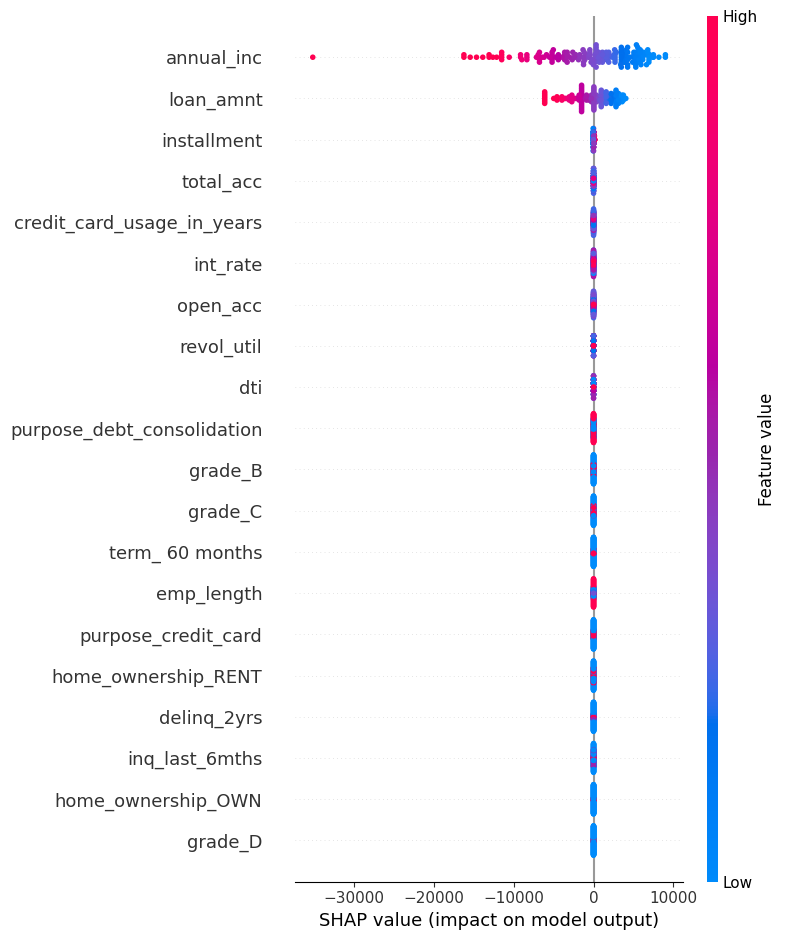

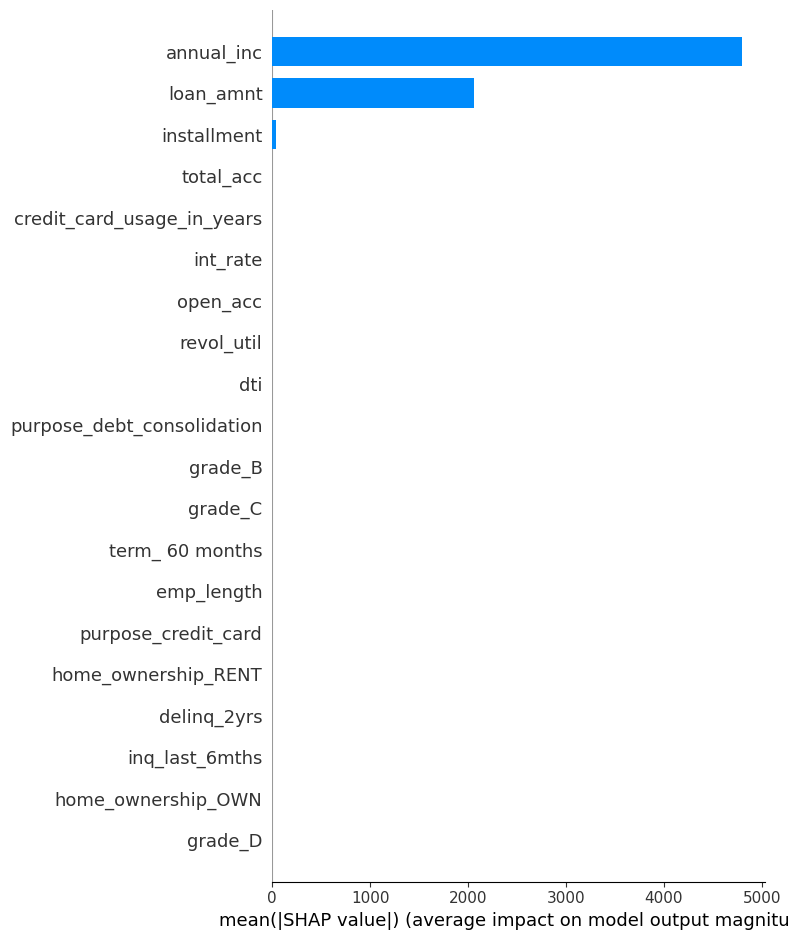

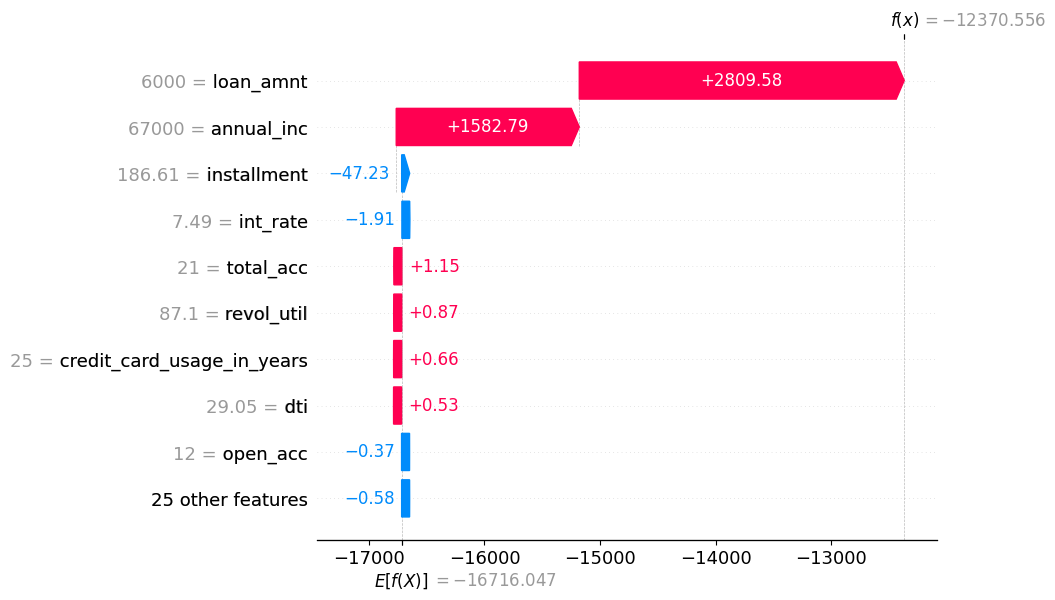

In [ ]:
xtrain = xtrain.astype(float)
xtest = xtest.astype(float)
explainer = shap.LinearExplainer(model, xtrain)
shap_values = explainer.shap_values(xtest)
shap.summary_plot(shap_values, xtest)
shap.summary_plot(shap_values, xtest, plot_type="bar")
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=xtest.iloc[0]
    )
)

In [10]:
import pandas as pd
df=pd.read_csv('/content/accepted_2007_to_2018Q4.csv')
print(df.head())
print(df.columns)

         id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0  68407277        NaN     3600.0       3600.0           3600.0   36 months   
1  68355089        NaN    24700.0      24700.0          24700.0   36 months   
2  68341763        NaN    20000.0      20000.0          20000.0   60 months   
3  66310712        NaN    35000.0      35000.0          35000.0   60 months   
4  68476807        NaN    10400.0      10400.0          10400.0   60 months   

   int_rate  installment grade sub_grade  ... hardship_payoff_balance_amount  \
0     13.99       123.03     C        C4  ...                            NaN   
1     11.99       820.28     C        C1  ...                            NaN   
2     10.78       432.66     B        B4  ...                            NaN   
3     14.85       829.90     C        C5  ...                            NaN   
4     22.45       289.91     F        F1  ...                            NaN   

  hardship_last_payment_amount disbursement_

/tmp/ipykernel_607/619080874.py:2: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('/content/accepted_2007_to_2018Q4.csv')


In [11]:
selected_features = [
    'loan_amnt', # requested loan
    'term', # loan duration
    'int_rate',# interest %
    'installment',# monthly payment
    'grade',# credit grade (A–G)
    'emp_length',# years working
    'home_ownership',# rent/own
    'annual_inc',# income
    'verification_status',# income verified?
    'purpose',# purpose
    'dti',# debt/income ratio
    'delinq_2yrs',# past missed payments
    'inq_last_6mths',# credit checks
    'open_acc',# active accounts
    'pub_rec',# public records
    'revol_util',# usage %
    'earliest_cr_line',# credit start
    'total_acc',# total accounts
    'loan_status'   # target
]
new_df=df[selected_features].copy()
print(new_df.head())

   loan_amnt        term  int_rate  installment grade emp_length  \
0     3600.0   36 months     13.99       123.03     C  10+ years   
1    24700.0   36 months     11.99       820.28     C  10+ years   
2    20000.0   60 months     10.78       432.66     B  10+ years   
3    35000.0   60 months     14.85       829.90     C  10+ years   
4    10400.0   60 months     22.45       289.91     F    3 years   

  home_ownership  annual_inc verification_status             purpose    dti  \
0       MORTGAGE     55000.0        Not Verified  debt_consolidation   5.91   
1       MORTGAGE     65000.0        Not Verified      small_business  16.06   
2       MORTGAGE     63000.0        Not Verified    home_improvement  10.78   
3       MORTGAGE    110000.0     Source Verified  debt_consolidation  17.06   
4       MORTGAGE    104433.0     Source Verified      major_purchase  25.37   

   delinq_2yrs  inq_last_6mths  open_acc  pub_rec  revol_util  \
0          0.0             1.0       7.0      0.0  

In [12]:
new_df=new_df[new_df['loan_status'].isin(['Fully Paid','Charged Off'])]
new_df['target']=new_df['loan_status'].map({
    'Fully Paid':0,
    'Charged Off':1
})
new_df.drop('loan_status',axis=1,inplace=True)
new_df.head()

#target extraction


,loan_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_util,earliest_cr_line,total_acc,target
0,3600.0,36 months,13.99,123.03,C,10+ years,MORTGAGE,55000.0,Not Verified,debt_consolidation,5.91,0.0,1.0,7.0,0.0,29.7,Aug-2003,13.0,0
1,24700.0,36 months,11.99,820.28,C,10+ years,MORTGAGE,65000.0,Not Verified,small_business,16.06,1.0,4.0,22.0,0.0,19.2,Dec-1999,38.0,0
2,20000.0,60 months,10.78,432.66,B,10+ years,MORTGAGE,63000.0,Not Verified,home_improvement,10.78,0.0,0.0,6.0,0.0,56.2,Aug-2000,18.0,0
4,10400.0,60 months,22.45,289.91,F,3 years,MORTGAGE,104433.0,Source Verified,major_purchase,25.37,1.0,3.0,12.0,0.0,64.5,Jun-1998,35.0,0
5,11950.0,36 months,13.44,405.18,C,4 years,RENT,34000.0,Source Verified,debt_consolidation,10.20,0.0,0.0,5.0,0.0,68.4,Oct-1987,6.0,0


In [13]:
# converting term to number
#new_df['term']=new_df['term'].str.extract(r'(\d+)').astype(int)

# handling the experience of employee along with missing values
new_df['emp_length']=new_df['emp_length'].str.extract(r'(\d+)')
new_df['emp_length']=new_df['emp_length'].fillna(0).astype(int)

# to handle the early credit history to years of credit usage
new_df['earliest_cr_line']=pd.to_datetime(new_df['earliest_cr_line'])
import datetime
new_df['credit_card_usage_in_years']=datetime.datetime.now().year-new_df['earliest_cr_line'].dt.year
new_df.drop('earliest_cr_line',axis=1,inplace=True)


/tmp/ipykernel_607/267800478.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  new_df['earliest_cr_line']=pd.to_datetime(new_df['earliest_cr_line'])


In [14]:
new_df.head()
new_df.info()
new_df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 26518 entries, 0 to 30024
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   loan_amnt                   26518 non-null  float64
 1   term                        26518 non-null  object 
 2   int_rate                    26518 non-null  float64
 3   installment                 26518 non-null  float64
 4   grade                       26518 non-null  object 
 5   emp_length                  26518 non-null  int64  
 6   home_ownership              26518 non-null  object 
 7   annual_inc                  26518 non-null  float64
 8   verification_status         26518 non-null  object 
 9   purpose                     26518 non-null  object 
 10  dti                         26517 non-null  float64
 11  delinq_2yrs                 26518 non-null  float64
 12  inq_last_6mths              26518 non-null  float64
 13  open_acc                    26518 no

,loan_amnt,int_rate,installment,emp_length,annual_inc,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_util,total_acc,target,credit_card_usage_in_years
count,26518.000000,26518.000000,26518.000000,26518.000000,2.651800e+04,26517.000000,26518.000000,26518.000000,26518.000000,26518.000000,26504.000000,26518.000000,26518.000000,26518.000000
mean,14322.010521,12.011197,429.147151,5.617203,7.798432e+04,19.170685,0.337959,0.615997,11.996908,0.247455,50.926653,25.310431,0.204239,27.231503
std,8647.600116,4.203857,255.622195,3.779410,8.065133e+04,10.673726,0.898038,0.897523,5.715409,0.652859,24.250375,12.112393,0.403152,7.685305
min,1000.000000,5.320000,30.540000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,4.000000,0.000000,14.000000
25%,7500.000000,9.170000,242.150000,2.000000,4.700000e+04,12.480000,0.000000,0.000000,8.000000,0.000000,32.600000,17.000000,0.000000,22.000000
50%,12000.000000,11.480000,369.570000,5.000000,6.500000e+04,18.650000,0.000000,0.000000,11.000000,0.000000,50.600000,24.000000,0.000000,26.000000
75%,20000.000000,14.480000,573.830000,10.000000,9.400000e+04,25.410000,0.000000,1.000000,15.000000,0.000000,69.400000,32.000000,0.000000,31.000000
max,35000.000000,28.990000,1354.660000,10.000000,8.700000e+06,999.000000,15.000000,5.000000,67.000000,23.000000,145.800000,111.000000,1.000000,76.000000


In [15]:
new_df.isnull().sum()
new_df.fillna(new_df.median(numeric_only=True),inplace=True)
new_df.fillna('unknown',inplace=True)
# convert categorical to numerical and drop the first one it will be automatically
#stimulated once remaining input is zero
new_df=pd.get_dummies(new_df,drop_first=True)


In [16]:
new_df['target'].value_counts(normalize=True) * 100

,proportion
target,
0,79.576137
1,20.423863


Accuracy: 0.6525220176140912

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.65      0.75      1019
           1       0.30      0.65      0.41       230

    accuracy                           0.65      1249
   macro avg       0.60      0.65      0.58      1249
weighted avg       0.78      0.65      0.69      1249


Confusion Matrix:
 [[665 354]
 [ 80 150]]



🔹 Threshold: 0.6
Confusion Matrix:
[[3463  739]
 [ 564  538]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      4202
           1       0.42      0.49      0.45      1102

    accuracy                           0.75      5304
   macro avg       0.64      0.66      0.65      5304
weighted avg       0.77      0.75      0.76      5304

   Threshold  Precision    Recall        F1
0        0.6     0.4213  0.488203  0.452291


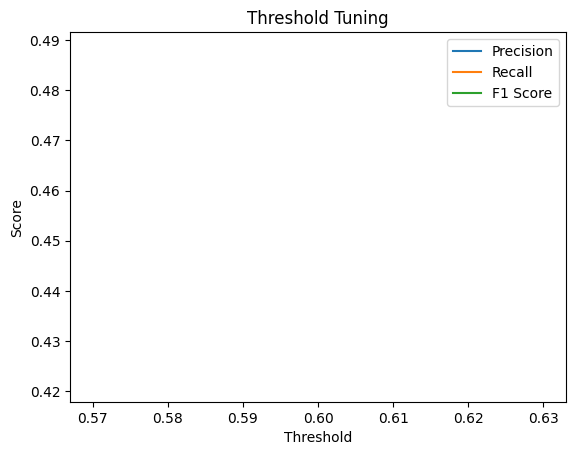

In [17]:
x=new_df.drop('target',axis=1)
y=new_df['target']

from sklearn.model_selection import train_test_split

xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
xtrsc=scaler.fit_transform(xtrain)
xtesc=scaler.transform(xtest)

from sklearn.linear_model import LogisticRegression
model=LogisticRegression(
    class_weight='balanced',
    max_iter=1000)
model.fit(xtrsc,ytrain)
y_prob = model.predict_proba(xtesc)[:, 1]

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

results = []


print(f"\n🔹 Threshold: {0.6}")

y_pred_t = (y_prob > 0.6).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(ytest, y_pred_t))

print("\nClassification Report:")
print(classification_report(ytest, y_pred_t))

precision = precision_score(ytest, y_pred_t)
recall = recall_score(ytest, y_pred_t)
f1 = f1_score(ytest, y_pred_t)

results.append([0.6, precision, recall, f1])
results_df = pd.DataFrame(results, columns=['Threshold', 'Precision', 'Recall', 'F1'])
print(results_df)
import matplotlib.pyplot as plt

plt.plot(results_df['Threshold'], results_df['Precision'], label='Precision')
plt.plot(results_df['Threshold'], results_df['Recall'], label='Recall')
plt.plot(results_df['Threshold'], results_df['F1'], label='F1 Score')

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning")
plt.legend()
plt.show()

In [14]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6
,
    class_weight='balanced',# important for imbalance
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
)

rf.fit(xtrain, ytrain)
y_prob_rf = rf.predict_proba(xtest)[:, 1]
y_pred_rf = rf.predict(xtest)
from sklearn.metrics import classification_report, confusion_matrix

print("Default Threshold (0.5):")
print(confusion_matrix(ytest, y_pred_rf))
print(classification_report(ytest, y_pred_rf))

Default Threshold (0.5):
[[737 282]
 [ 91 139]]
              precision    recall  f1-score   support

           0       0.89      0.72      0.80      1019
           1       0.33      0.60      0.43       230

    accuracy                           0.70      1249
   macro avg       0.61      0.66      0.61      1249
weighted avg       0.79      0.70      0.73      1249



In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6
,
    class_weight='balanced',# important for imbalance
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
)

rf.fit(xtrain, ytrain)
y_prob_rf = rf.predict_proba(xtest)[:, 1]
from sklearn.metrics import classification_report, confusion_matrix

print(f"\n🔹 Threshold: {0.4}")

y_pred_t = (y_prob_rf > 0.4).astype(int)

print(confusion_matrix(ytest, y_pred_t))
print(classification_report(ytest, y_pred_t))


🔹 Threshold: 0.4
[[510 509]
 [ 52 178]]
              precision    recall  f1-score   support

           0       0.91      0.50      0.65      1019
           1       0.26      0.77      0.39       230

    accuracy                           0.55      1249
   macro avg       0.58      0.64      0.52      1249
weighted avg       0.79      0.55      0.60      1249



In [16]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6
,
    class_weight='balanced',# important for imbalance
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
)

rf.fit(xtrain, ytrain)
y_prob_rf = rf.predict_proba(xtest)[:, 1]
from sklearn.metrics import classification_report, confusion_matrix

print(f"\n🔹 Threshold: {0.4}")

y_pred_t = (y_prob_rf > 0.4).astype(int)

print(confusion_matrix(ytest, y_pred_t))
print(classification_report(ytest, y_pred_t))


🔹 Threshold: 0.4
[[510 509]
 [ 52 178]]
              precision    recall  f1-score   support

           0       0.91      0.50      0.65      1019
           1       0.26      0.77      0.39       230

    accuracy                           0.55      1249
   macro avg       0.58      0.64      0.52      1249
weighted avg       0.79      0.55      0.60      1249



In [18]:
!pip install xgboost

In [21]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

param_dist = {
    "scale_pos_weight": [5, 8, 10, 12, 15],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.03, 0.05, 0.1],
    "n_estimators": [300, 500, 700],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.5, 1],
}

xgb = XGBClassifier(
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=25,                 # 🔥 try 20–40 depending on time
    scoring='f1',
    cv=cv,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(xtrain, ytrain)

print("Best Params:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best Params: {'scale_pos_weight': 5, 'n_estimators': 700, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.03, 'gamma': 1}
Best Score: 0.4484645032823867


In [22]:
best_xgb = random_search.best_estimator_
y_prob = best_xgb.predict_proba(xtest)[:, 1]

thresholds = [0.2, 0.3, 0.4, 0.5, 0.6]

for t in thresholds:
    print(f"\n🔹 Threshold: {t}")

    y_pred_t = (y_prob > t).astype(int)

    print(confusion_matrix(ytest, y_pred_t))
    print(classification_report(ytest, y_pred_t))


🔹 Threshold: 0.2
[[ 654 3548]
 [  32 1070]]
              precision    recall  f1-score   support

           0       0.95      0.16      0.27      4202
           1       0.23      0.97      0.37      1102

    accuracy                           0.33      5304
   macro avg       0.59      0.56      0.32      5304
weighted avg       0.80      0.33      0.29      5304


🔹 Threshold: 0.3
[[1209 2993]
 [  89 1013]]
              precision    recall  f1-score   support

           0       0.93      0.29      0.44      4202
           1       0.25      0.92      0.40      1102

    accuracy                           0.42      5304
   macro avg       0.59      0.60      0.42      5304
weighted avg       0.79      0.42      0.43      5304


🔹 Threshold: 0.4
[[1833 2369]
 [ 156  946]]
              precision    recall  f1-score   support

           0       0.92      0.44      0.59      4202
           1       0.29      0.86      0.43      1102

    accuracy                           0.52    